# Grupo 2 — Series temporales y pronóstico de consumo eléctrico



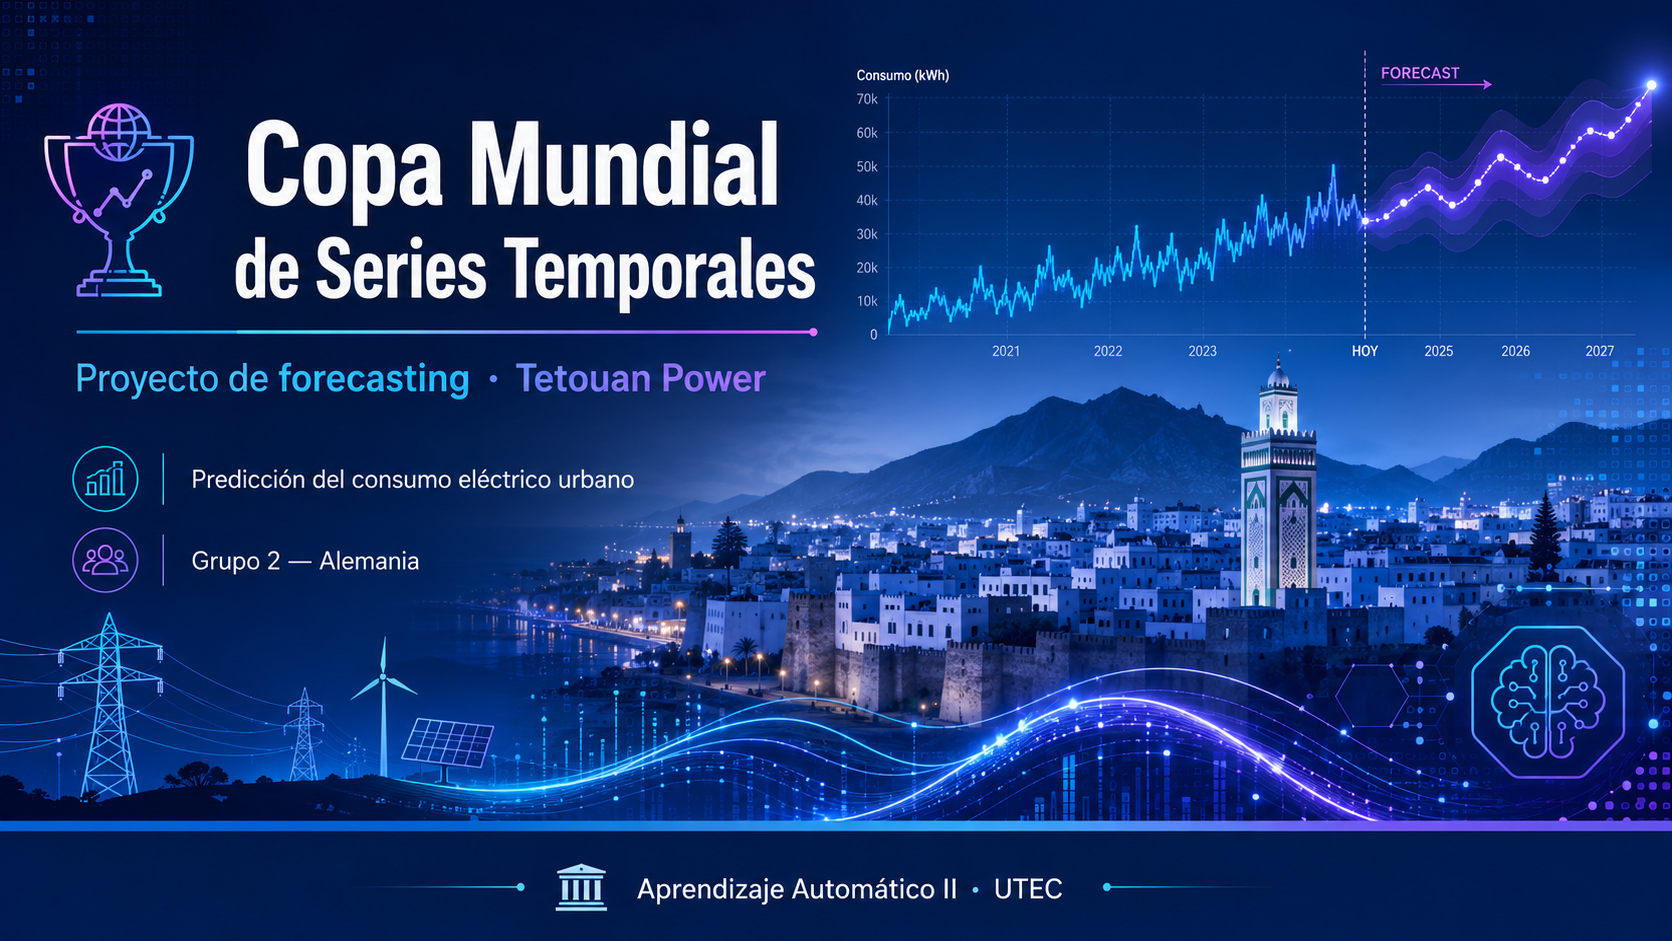


**Variable objetivo:** `consumo_zona_1`  
**Variables exógenas:** `temperatura`, `humedad`, `velocidad_viento`, `flujo_difuso_general`, `flujo_difuso`.

## 1. Importación de librerías


In [1]:
#Instala la libreria LightGBM, que sirve para usar el modelo LGBMRegressor
!pip install lightgbm

In [2]:
#Instala skforecast, que sirve para hacer modelos de series temporales
!pip install skforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.8 MB/s eta 0:00:00


In [3]:
import warnings #importa librerias warnings que maneja advertencias del sistema
warnings.filterwarnings("ignore") #oculta las advertencias para que el notebook se ve más limpio

from pathlib import Path #maneja rutas de archivos y carpetas
import json
import joblib #guarda y carga modelos entrenados

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #importa funciones para graficar ACF y PACF

from sklearn.linear_model import Ridge #importa el modelo Ridge
from sklearn.ensemble import RandomForestRegressor #importa el modelo Random Forest para regresión
from sklearn.metrics import mean_absolute_error #importa la metrica MAE para medir el error

from lightgbm import LGBMRegressor # Importa el modelo LightGBM para regresión

from skforecast.recursive import ForecasterRecursive #importa el forecast recursivo de skforecast
from skforecast.direct import ForecasterDirect #importa el forecast directo de skforecast
from skforecast.model_selection import TimeSeriesFold # sirve para hacer particiones respetando el tiempo
from skforecast.model_selection import backtesting_forecaster # sirve para evaluar el modelo con backtesting
from skforecast.model_selection import grid_search_forecaster # sirve para buscar mejores hiperparametros

pd.set_option("display.max_columns", None) # hace que pandas muestre todas las columnas del Dataframe
pd.set_option("display.width", 120)# ajusta el ancho de visualización de las tablas

RANDOM_STATE = 123 # fija una semilla para que los resultados sean reproducibles

## 2. Carga del dataset

In [4]:
#Descarga desde google drive el archivo con ese id y lo guarda en colab con el nombre alemania_consumo.csv
!gdown --id 12f2d0Lu2XGHA9bXE4D3KsgDuyY_NFljU -O alemania_consumo.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=12f2d0Lu2XGHA9bXE4D3KsgDuyY_NFljU
To: /content/alemania_consumo.csv
100% 2.95M/2.95M [00:00<00:00, 82.4MB/s]


In [5]:
DATA_PATH = Path("tetuan_power_docente.csv")#carga la ruta del archivo CSV en una variable

df = pd.read_csv("alemania_consumo.csv") #lee el archivo CSV y lo carga en un dataframe llamado df

print(f"Filas: {df.shape[0]:,}") #muestra la cantidad de filas del dataset
print(f"Columnas: {df.shape[1]}") #muestra la cantidad de columnas del dataset
display(df.head()) #muestra las primeras 5 filas del dataset
display(df.tail()) #muestra las últimas 5 filas del dataset

Filas: 52,416
Columnas: 7


,fecha,consumo_zona_1,temperatura,humedad,velocidad_viento,flujo_difuso_general,flujo_difuso
0,1/1/2017 0:00,34055.69620,6.559,73.8,0.083,0.051,0.119
1,1/1/2017 0:10,29814.68354,6.414,74.5,0.083,0.070,0.085
2,1/1/2017 0:20,29128.10127,6.313,74.5,0.080,0.062,0.100
3,1/1/2017 0:30,28228.86076,6.121,75.0,0.083,0.091,0.096
4,1/1/2017 0:40,27335.69620,5.921,75.7,0.081,0.048,0.085


,fecha,consumo_zona_1,temperatura,humedad,velocidad_viento,flujo_difuso_general,flujo_difuso
52411,12/30/2017 23:10,31160.45627,7.010,72.4,0.080,0.040,0.096
52412,12/30/2017 23:20,30430.41825,6.947,72.6,0.082,0.051,0.093
52413,12/30/2017 23:30,29590.87452,6.900,72.8,0.086,0.084,0.074
52414,12/30/2017 23:40,28958.17490,6.758,73.0,0.080,0.066,0.089
52415,12/30/2017 23:50,28349.80989,6.580,74.1,0.081,0.062,0.111


## 3. Exploración de datos

En esta etapa se revisan tipos de datos, nulos, duplicados, estadísticos generales y gráficos iniciales.  
También se incluye la **PACF** para orientar la selección de lags a probar.

Como el dataset original está cada 10 minutos, para la PACF se usa una versión horaria preliminar de la serie.

In [6]:
display(df.info()) #muestra información general del dataset
display(df.describe().T) # muestra estadísticas de las columnas

print("Valores faltantes por columna:")
display(df.isna().sum()) #cuenta cuantos valores faltantes hay en cada columna

print("Duplicados completos:")
print(df.duplicated().sum()) #cuenta cuantas columnas completas estan repetidas

print("Duplicados por fecha:")
print(df["fecha"].duplicated().sum()) #cuenta cuantos registros tienen una fecha repetida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 52416 non-null  object 
 1   consumo_zona_1        52386 non-null  float64
 2   temperatura           52386 non-null  float64
 3   humedad               52386 non-null  float64
 4   velocidad_viento      52386 non-null  float64
 5   flujo_difuso_general  52386 non-null  float64
 6   flujo_difuso          52386 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


None

,count,mean,std,min,25%,50%,75%,max
consumo_zona_1,52386.0,32345.225369,7132.043684,13895.6962,26308.67257,32265.92034,37313.96061,52204.39512
temperatura,52386.0,18.808778,5.815192,3.2470,14.41000,18.78000,22.89000,40.01000
humedad,52386.0,68.258503,15.553522,11.3400,58.31000,69.86000,81.40000,94.80000
velocidad_viento,52386.0,1.960478,2.349078,0.0500,0.07800,0.08600,4.91500,6.48300
flujo_difuso_general,52386.0,182.654006,264.337883,0.0040,0.06200,5.04250,319.60000,1163.00000
flujo_difuso,52386.0,75.033923,124.233233,0.0110,0.12200,4.46750,100.97500,936.00000


Valores faltantes por columna:


,0
fecha,0
consumo_zona_1,30
temperatura,30
humedad,30
velocidad_viento,30
flujo_difuso_general,30
flujo_difuso,30


Duplicados completos:
0
Duplicados por fecha:
0


In [7]:
#en esta parte vamos a convertir la columna fecha a fromato datatime para poder analizarla como
#serie temporal.
#el formato de la fecha en el archivo es mes/día/año hora:minuto

df_eda = df.copy() #crea una copia del dataset

#convierte la columna fecha a formato datetime; si alguna fecha esta mal la convierte en NaT
df_eda["fecha"] = pd.to_datetime(df_eda["fecha"], format="%m/%d/%Y %H:%M", errors="coerce")

print("Fechas no parseadas:", df_eda["fecha"].isna().sum()) #cuenta cuantas fechas no se pudieron convertir
print("Fecha mínima:", df_eda["fecha"].min()) # muestra la primera fecha del dataset
print("Fecha máxima:", df_eda["fecha"].max()) #muestra la ultima fecha del dataset

df_eda = df_eda.set_index("fecha").sort_index() #pone fecha como índice y ordena los datos cronológicamente

Fechas no parseadas: 0
Fecha mínima: 2017-01-01 00:00:00
Fecha máxima: 2017-12-30 23:50:00


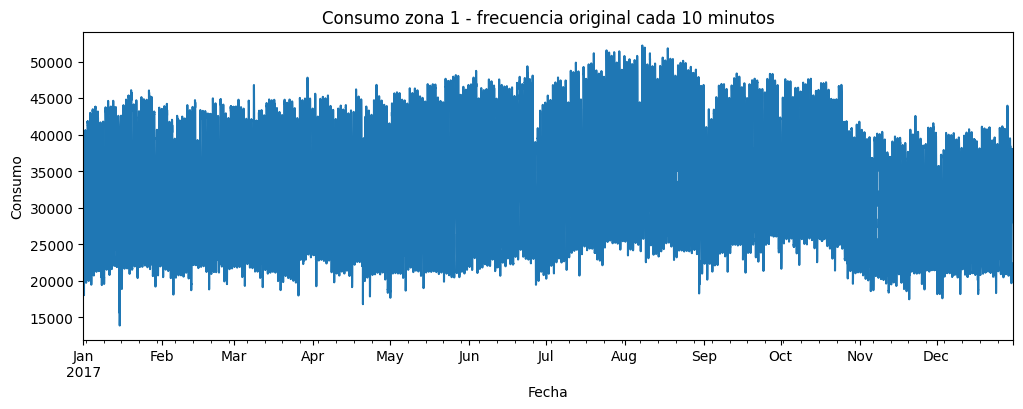

In [8]:
# Serie objetivo original cada 10 minutos

TARGET_ORIGINAL = "consumo_zona_1" #guarda el nombre de la variable objetivo que se quiere analizar y predecir

fig, ax = plt.subplots(figsize=(12, 4)) #crea el espacio para el gráfico con tamaño 12x4
df_eda[TARGET_ORIGINAL].plot(ax=ax) #grafica la columna consumo_xona_1 usando la fecha como eje X
ax.set_title("Consumo zona 1 - frecuencia original cada 10 minutos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Consumo")
plt.show() #muestra el gráfico

In [9]:
# Versión horaria preliminar para ACF/PACF

serie_horaria_pacf = (      #crea una serie horaria para usar en los gráficos ACF y PACF
    df_eda[TARGET_ORIGINAL] #selecciona la variable objetivo: consumo_zona_1
    .resample("h")          # agrupa los datos por hora
    .mean()                 # calcula el promedio de consumo dentro de cada hora
    .asfreq("h")            # asegura que la serie tenga frecuencia horaria regular
    .interpolate(method="time") # rellena valores faltantes usando interpolación segun el tiempo
    .ffill()                # si queda algún nulo, lo rellena con el valor anterior
                            # si queda algun nulo en el inicio, lo rellena con el valor siguiente.
    .bfill()
)

#muestra cuantos registros horarios tiene la serie
print(f"Cantidad de registros horarios preliminares: {len(serie_horaria_pacf):,}")

#muestra cuantos nulos quedaron despues del relleno
print(f"Nulos luego de imputación preliminar: {serie_horaria_pacf.isna().sum()}")

Cantidad de registros horarios preliminares: 8,736
Nulos luego de imputación preliminar: 0


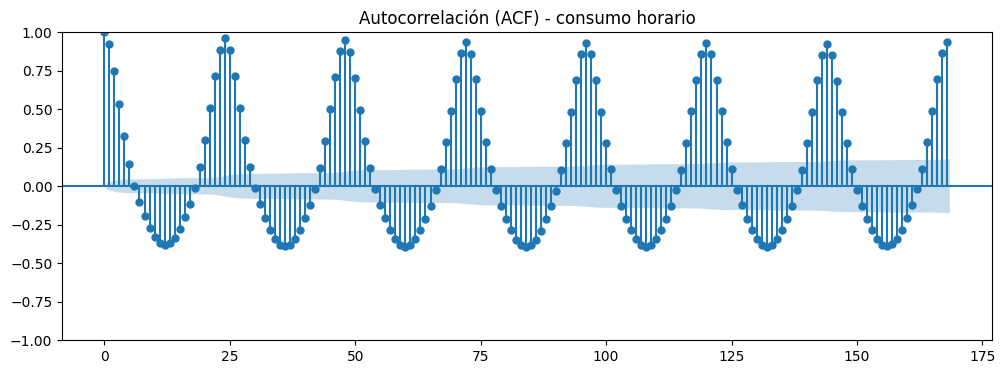

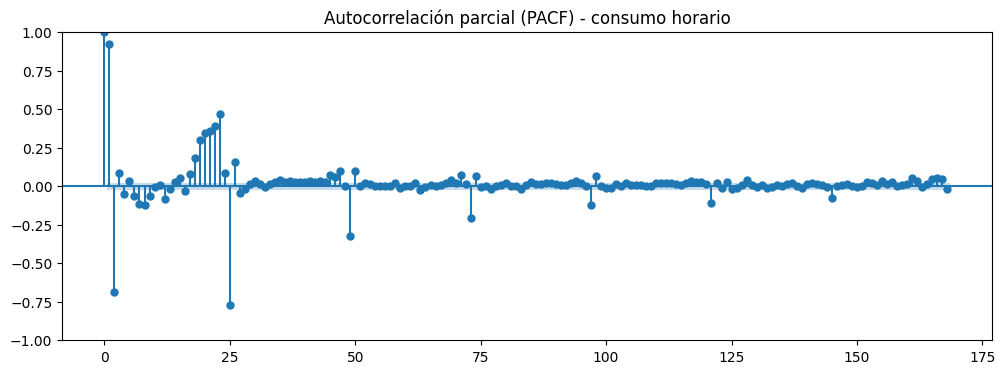

In [10]:
#define cuantos lags se van a analizar; 168 lags = 1 semana
max_lags = 168

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(serie_horaria_pacf, lags=max_lags, ax=ax) #grafica la autocorrelación de la serie horaria
ax.set_title("Autocorrelación (ACF) - consumo horario")
plt.show() #muestra el gráfico ACF

fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(serie_horaria_pacf, lags=max_lags, method="ywm", ax=ax)#grafica la autocorrelación parcial de la serie horaria
ax.set_title("Autocorrelación parcial (PACF) - consumo horario")
plt.show() #muestra el gráfico PACF

## 4. Cambiar la fecha a un registro por hora

Se convierte `fecha` a índice temporal y se agrupan los registros de 10 minutos a frecuencia horaria usando el promedio.

In [11]:
data = df.copy() # crea una copia del dataset

# convierte la columna fecha a formato datetime; si alguna fecha esta mal la convierte en NaT
data["fecha"] = pd.to_datetime(data["fecha"], format="%m/%d/%Y %H:%M", errors="coerce")

# Se eliminan filas sin fecha válida si existieran.
data = data.dropna(subset=["fecha"])

#coloca fecha como índice y ordena los datos cronológicamente
data = data.set_index("fecha").sort_index()

#agrupa los datos por hora y calcula el promedio de los registros de 10 minutos
data = data.resample("h").mean().asfreq("h")

#renombra la variable objetivo consumo_zona_1 como y
data = data.rename(columns={"consumo_zona_1": "y"})

TARGET = "y" #guarda el nombre de la variable objetivo que se quiere predecir

#lista de variables exógenas que pueden ayudar a predecir el consumo
EXOG_COLS = [
    "temperatura",
    "humedad",
    "velocidad_viento",
    "flujo_difuso_general",
    "flujo_difuso"
]

print(f"Filas horarias: {data.shape[0]:,}") #muestra cuantas filas tiene el dataset despues de paqsarlo a frecuencia horaria
print(f"Columnas: {data.shape[1]}") #muestra cuantas columnas tiene el dataset
print("Rango temporal:", data.index.min(), "---", data.index.max())#muestra la primera y ultima fecha del dataset
display(data.head()) #muestra las primeras 5 filas del dataset preparado
display(data.tail())# muestra las últimas 5 filas del dataset preparado

print("Nulos después de pasar a frecuencia horaria:")
display(data.isna().sum())#cuenta cuántos valores faltantes hay en cada columna después del cambio a frecuencia horaria

Filas horarias: 8,736
Columnas: 6
Rango temporal: 2017-01-01 00:00:00 --- 2017-12-30 23:00:00


,y,temperatura,humedad,velocidad_viento,flujo_difuso_general,flujo_difuso
fecha,,,,,,
2017-01-01 00:00:00,29197.974683,6.196833,75.066667,0.081833,0.063500,0.098833
2017-01-01 01:00:00,24657.215190,5.548833,77.583333,0.082000,0.056833,0.112500
2017-01-01 02:00:00,22083.037973,5.054333,78.933333,0.082333,0.063000,0.129167
2017-01-01 03:00:00,20811.139240,5.004333,77.083333,0.082833,0.059833,0.141000
2017-01-01 04:00:00,20475.949367,5.097667,74.050000,0.082333,0.058000,0.122833


,y,temperatura,humedad,velocidad_viento,flujo_difuso_general,flujo_difuso
fecha,,,,,,
2017-12-30 19:00:00,37513.814957,9.453333,62.406667,0.074667,0.052000,0.102000
2017-12-30 20:00:00,37008.871988,9.041667,63.990000,0.080333,0.052667,0.105000
2017-12-30 21:00:00,35358.174905,8.011667,69.675000,0.081500,0.073167,0.098333
2017-12-30 22:00:00,33993.409380,7.598333,70.315000,0.081833,0.058667,0.108167
2017-12-30 23:00:00,30107.984788,6.877500,72.900000,0.081500,0.060333,0.092667


Nulos después de pasar a frecuencia horaria:


,0
y,3
temperatura,3
humedad,3
velocidad_viento,3
flujo_difuso_general,3
flujo_difuso,3


## 4.1 Gráficos exploratorios sobre la serie horaria

Luego de convertir la serie a frecuencia horaria, se agregan gráficos para analizar:

- Consumo eléctrico durante la primera semana.
- Boxplot del consumo eléctrico y posibles outliers.
- Consumo promedio por hora del día.
- Consumo promedio por día de la semana.

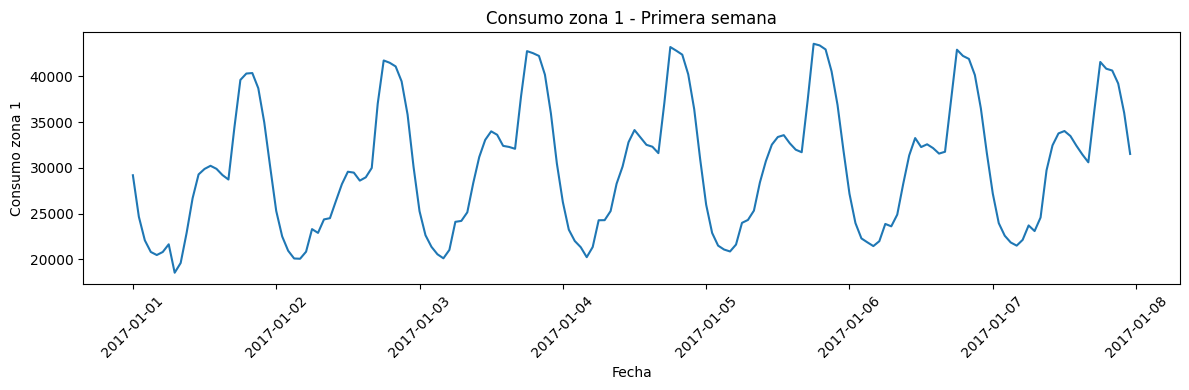

In [12]:
# Consumo eléctrico durante la primera semana

n_primera_semana = min(24 * 7, len(data)) #calcula cuantas horas se van a graficar: maximo 168 horas

plt.figure(figsize=(12, 4))
#grafica el consumo de la primera semana usando la fecha en el eje X y el consumo en el eje Y
plt.plot(data.index[:n_primera_semana], data[TARGET].iloc[:n_primera_semana])
plt.title("Consumo zona 1 - Primera semana")
plt.xlabel("Fecha")
plt.ylabel("Consumo zona 1")
plt.xticks(rotation=45) #rota las fechas del eje x para que se lean mejor
plt.tight_layout() #ajusta el gráfico para que los textos no se corten
plt.show() # muestra el gráfico

Límite inferior: 9752.765639166671
Límite superior: 53859.701325833325
Cantidad de posibles outliers: 0


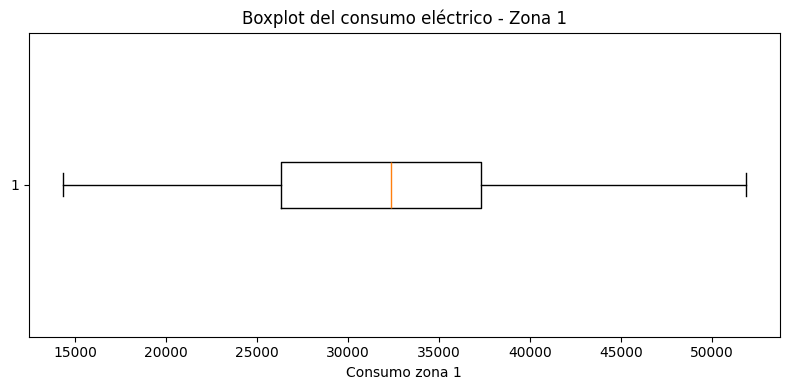

In [13]:
# Boxplot de consumo eléctrico y detección de posibles outliers por IQR

#calcula el primer cuartil: el 25% de los datos quedan por debajo de este valor
q1 = data[TARGET].quantile(0.25)

#calcula el tercer cuartil: el 75% de los datos quedan por debajo de este valor
q3 = data[TARGET].quantile(0.75)
iqr = q3 - q1 #calcula el rango intercuatrílico, mide la disperción central de los datos

limite_inferior = q1 - 1.5 * iqr #calcula el limite inferior para detectar posibles outliers
limite_superior = q3 + 1.5 * iqr #calcula el límite superior para detectar posibles outliers

#filtra los registros cuyo consumo está por debajo o por encima de los límites
outliers = data[(data[TARGET] < limite_inferior) | (data[TARGET] > limite_superior)]

print("Límite inferior:", limite_inferior) #muestra el limite inferior calculado
print("Límite superior:", limite_superior) #muestra el límite superior calculado
print("Cantidad de posibles outliers:", len(outliers))#muestra cuantos posibles outliers se encontraron

plt.figure(figsize=(8, 4))
plt.boxplot(data[TARGET].dropna(), vert=False) #crea un boxplot horizontal del consumo, ignorando valores nulos
plt.title("Boxplot del consumo eléctrico - Zona 1")
plt.xlabel("Consumo zona 1")
plt.tight_layout() #ajusta el gráfico para que no se corten los textos
plt.show() #muestra el gráfico

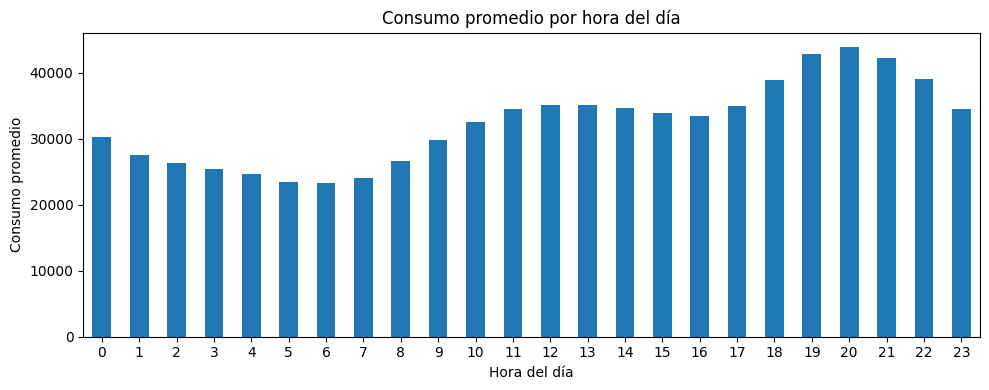

In [14]:
# Consumo promedio por hora del día

eda = data.copy() #crea una copia del dataset para hacer un análisis exploratorio
eda["hora"] = eda.index.hour #crea una columna con la hora del día tomada del índice de fecha
eda["dia_semana"] = eda.index.dayofweek #crea una columna con el día de la semana: lunes=0, domingo=6
eda["mes"] = eda.index.month #crea una columna con el numéro del mes

#agrupa por hora del día y calcula el consumo promedio en cada hora
consumo_por_hora = eda.groupby("hora")[TARGET].mean()

plt.figure(figsize=(10, 4))
consumo_por_hora.plot(kind="bar") #grafica el consumo promedio por hora en un gráfico de barras
plt.title("Consumo promedio por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Consumo promedio")
plt.xticks(rotation=0) #deja los numeros de las horas sin rotacion
plt.tight_layout() #ajusta el grafico para que no se corten los textos
plt.show() #muestra el grafico

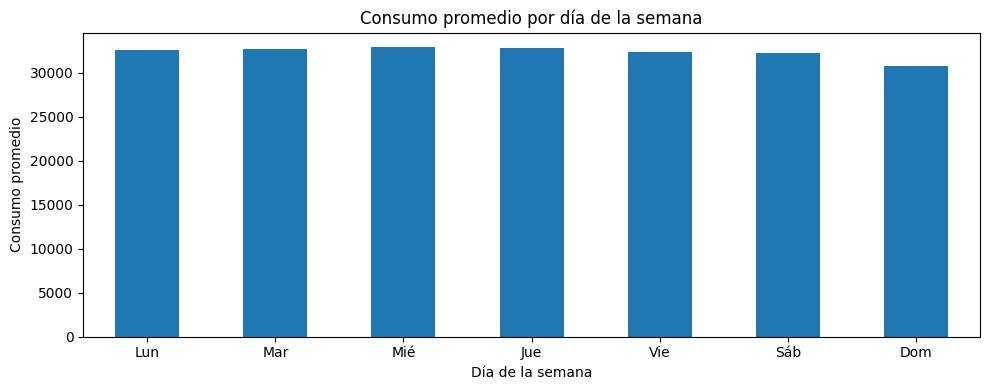

In [15]:
# Consumo promedio por día de la semana

#agrupa los datos por día de la semana y calcula el consumo promedio
consumo_por_dia = eda.groupby("dia_semana")[TARGET].mean()

plt.figure(figsize=(10, 4))
consumo_por_dia.plot(kind="bar") #grafica el consumo promedio por día de la semana en barras
plt.title("Consumo promedio por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Consumo promedio")
plt.xticks(
    ticks=range(7), #define las posiciones de las etiquetas del eje X, del 0 al 6
    labels=["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"], #cambia los numeros por nombres de días
    rotation=0
)
plt.tight_layout()
plt.show()

## 5. Separar en train, validación y test

Para evitar fuga de información, la separación se hace respetando el orden temporal.

- `train`: entrenamiento inicial.
- `validación`: búsqueda de hiperparámetros, lags y comparación interna.
- `test`: evaluación final no vista.

In [16]:
# Proporciones:
# 64% train, 16% validación y 20% test.
n_total = len(data) #calcula la cantidad total de registros del dataset
n_test = int(n_total * 0.20) # calcula el 20% de los datos de test
n_train_val = n_total - n_test #calcula el 80% restante para train
n_val = int(n_train_val * 0.20)# Calcula el 20% de train + validación para validación
n_train = n_train_val - n_val # El resto queda para entrenamiento

data_train_raw = data.iloc[:n_train].copy() #toma los primeros datos para entrenamiento
data_val_raw = data.iloc[n_train:n_train_val].copy() #toma los datos siguientes para validación
data_train_val_raw = data.iloc[:n_train_val].copy() #une enytrenamiento y validación
data_test_raw = data.iloc[n_train_val:].copy() #agarra los ultimos datos para para test

print(f"Total:        {len(data):,}") #muestra la cantidad total de registros
# Muestra cantidad y rango de fechas de train
print(f"Train:        {len(data_train_raw):,} | {data_train_raw.index.min()} --- {data_train_raw.index.max()}")

 # Muestra cantidad y rango de fechas de validación
print(f"Validación:   {len(data_val_raw):,} | {data_val_raw.index.min()} --- {data_val_raw.index.max()}")

# Muestra cantidad y rango de fechas de train + validación
print(f"Train + val:  {len(data_train_val_raw):,} | {data_train_val_raw.index.min()} --- {data_train_val_raw.index.max()}")

# Muestra cantidad y rango de fechas de test
print(f"Test:         {len(data_test_raw):,} | {data_test_raw.index.min()} --- {data_test_raw.index.max()}")

Total:        8,736
Train:        5,592 | 2017-01-01 00:00:00 --- 2017-08-21 23:00:00
Validación:   1,397 | 2017-08-22 00:00:00 --- 2017-10-19 04:00:00
Train + val:  6,989 | 2017-01-01 00:00:00 --- 2017-10-19 04:00:00
Test:         1,747 | 2017-10-19 05:00:00 --- 2017-12-30 23:00:00


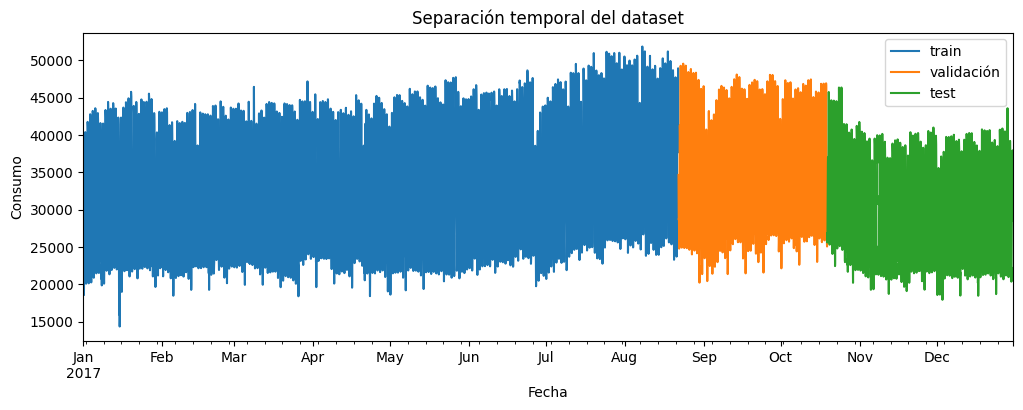

In [17]:
# Gráfico de la separación temporal
fig, ax = plt.subplots(figsize=(12, 4))
data_train_raw[TARGET].plot(ax=ax, label="train")
data_val_raw[TARGET].plot(ax=ax, label="validación")
data_test_raw[TARGET].plot(ax=ax, label="test")
ax.set_title("Separación temporal del dataset")
ax.set_xlabel("Fecha")
ax.set_ylabel("Consumo")
ax.legend()
plt.show()

## 6. Imputar valores faltantes

Se imputan valores faltantes por bloque temporal, evitando mezclar train, validación y test antes de la separación.

Estrategia:
1. Interpolación temporal.
2. Forward fill.
3. Backward fill.

In [18]:
def imputar_temporal(df_bloque): #define una función para rellenar valores faltantes en un bloque de datos
    '''
    Imputa valores faltantes en un bloque temporal.
    '''
    df_bloque = df_bloque.copy() #crea una copia para no modificar el bloque original
    df_bloque = df_bloque.interpolate(method="time") #rellena nulos usando interpolación según el tiempo
    df_bloque = df_bloque.ffill().bfill() # rellena posibles nulos restantes con el valor anterior y luego con el siguiente
    return df_bloque #devuelve el bloque ya imputado

# Imputa valores faltantes en el conjunto de entrenamiento
data_train = imputar_temporal(data_train_raw)

# Imputa valores faltantes en el conjunto de validación
data_val = imputar_temporal(data_val_raw)

# Imputa valores faltantes en entrenamiento + validación
data_train_val = imputar_temporal(data_train_val_raw)

 # Imputa valores faltantes en el conjunto de test
data_test = imputar_temporal(data_test_raw)

 # Une train, validación y test ya imputados en un solo dataset
data_imputed = pd.concat([data_train, data_val, data_test], axis=0)

print("Nulos en train:")
display(data_train.isna().sum())

print("Nulos en validación:")
display(data_val.isna().sum())

print("Nulos en test:")
display(data_test.isna().sum())

print("Nulos en dataset completo imputado:")
display(data_imputed.isna().sum())

Nulos en train:


,0
y,0
temperatura,0
humedad,0
velocidad_viento,0
flujo_difuso_general,0
flujo_difuso,0


Nulos en validación:


,0
y,0
temperatura,0
humedad,0
velocidad_viento,0
flujo_difuso_general,0
flujo_difuso,0


Nulos en test:


,0
y,0
temperatura,0
humedad,0
velocidad_viento,0
flujo_difuso_general,0
flujo_difuso,0


Nulos en dataset completo imputado:


,0
y,0
temperatura,0
humedad,0
velocidad_viento,0
flujo_difuso_general,0
flujo_difuso,0


In [19]:
#Guardar dataset horario e imputado

# Crear carpeta data/processed si no existe
output_dir = Path("data") / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

# Ruta final del archivo
output_path = output_dir / "consumo_horario_procesado.csv"

# Guardar dataset completo horario e imputado
data_imputed.to_csv(
    output_path,
    index=True,
    index_label="fecha"
)

print("Dataset horario e imputado guardado correctamente en:")
print(output_path) # Muestra la ruta donde se guardó el archivo

Dataset horario e imputado guardado correctamente en:
data/processed/consumo_horario_procesado.csv


## 7. Modelo base univariante

Se usa un modelo sencillo con `Ridge` para comparar tres combinaciones:

1. **Ventana fija + estrategia recursiva**  
2. **Ventana fija + estrategia directa**  
3. **Ventana deslizante + la mejor estrategia anterior**

En este notebook se interpreta:

- **Ventana fija**: el modelo se entrena una vez sobre train y se evalúa sobre validación sin reentrenar en cada fold (`refit=False`).
- **Ventana deslizante**: backtesting walk-forward con reentrenamiento y tamaño de entrenamiento fijo (`refit=True`, `fixed_train_size=True`).

La métrica de comparación es **MAE**.

In [20]:
#parámetros generales de forecasting


#horizonte de predicción:
#24 pasos horarios = predicción de las próximas 24 horas.
STEPS = 24

#lags iniciales guiados por frecuencia horaria:
# 1, 2, 3 = dinámica reciente
# 23, 24, 25 = patrón diario
# 47, 48, 49 = patrón de dos días
# 167, 168 = patrón semanal
BASE_LAGS = [1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]

#define una función para obtener el MAE aunque skforecast lo devuelva en distintos formatos
def extraer_mae(metric):
    if isinstance(metric, pd.DataFrame):  #revisa si la métrica viene como DataFrame
        if "mean_absolute_error" in metric.columns: #si existe la columna mean_absolute_error
            return float(metric["mean_absolute_error"].iloc[0])  #devuelve el primer valor de esa columna como número decimal
        return float(metric.iloc[0, 0]) #si no existe esa columna, devuelve el primer valor del DataFrame

    if isinstance(metric, pd.Series):   #revisa si la métrica viene como Series
        if "mean_absolute_error" in metric.index:   #si existe el índice mean_absolute_error
            return float(metric.loc["mean_absolute_error"])   #devuelve ese valor como número decimal
        return float(metric.iloc[0]) #si no existe ese índice, devuelve el primer valor de la Series
    return float(metric) #si la métrica ya viene como número, la convierte a float y la devuelve

#define una función para evaluar un modelo usando backtesting
def evaluar_backtesting(
    forecaster,
    y,
    initial_train_size,
    nombre,
    exog=None,
    refit=False,
    fixed_train_size=False,
    show_progress=True
):
    '''
    Evalúa un forecaster con backtesting y devuelve MAE + predicciones.
    '''
    cv = TimeSeriesFold(
        steps=STEPS,  #en cada evaluación predice 24 horas hacia adelante
        initial_train_size=initial_train_size, #define cuántos datos iniciales se usan para entrenar
        refit=refit,    #indica si el modelo se vuelve a entrenar en cada fold
        fixed_train_size=fixed_train_size,    #indica si el tamaño del entrenamiento queda fijo o va creciendo
        gap=0,  #no deja separación entre entrenamiento y predicción
        allow_incomplete_fold=True  #permite que el último bloque tenga menos de 24 datos si no alcanza
    )
#modelo de forecasting que se quiere evaluar
    metric, predictions = backtesting_forecaster(
        forecaster=forecaster,
        y=y, #serie temporal objetivo
        exog=exog, #variables exógenas, si se usan
        cv=cv, #estrategia de validación temporal definida arriba
        metric="mean_absolute_error",
        n_jobs="auto", #usa automáticamente los recursos disponibles para acelerar el cálculo
        verbose=False, #no muestra mensajes detallados
        show_progress=show_progress #muestra o no la barra de progreso
    )

    mae = extraer_mae(metric) #extrae el valor del MAE en formato numérico

    return {
        "modelo": nombre,
        "mae": mae,
        "metric": metric,
        "predictions": predictions, #predicciones generadas en el backtesting
        "forecaster": forecaster #modelo evaluado
    }

In [21]:


forecaster_base_recursivo = ForecasterRecursive(
    estimator=Ridge(), #usa el modelo Ridge como regresor base
    lags=BASE_LAGS #usa los valores pasados definidos en BASE_LAGS para predecir
)

resultado_base_recursivo = evaluar_backtesting(
    forecaster=forecaster_base_recursivo, #modelo que se va a evaluar
    y=data_train_val[TARGET], #serie objetivo usada para entrenamiento y validación
    initial_train_size=len(data_train),  #usa el tamaño de train como entrenamiento inicial
    nombre="base_ridge_univariante_recursivo_ventana_fija",
    exog=None, #no usa variables exógenas, solo la serie objetivo
    refit=False, #no vuelve a entrenar el modelo en cada paso del backtesting
    fixed_train_size=False #la ventana de entrenamiento no queda fija, puede ir creciendo
)

print("MAE base recursivo ventana fija:", resultado_base_recursivo["mae"])#muestra el error MAE obtenido

  0%|          | 0/59 [00:00<?, ?it/s]

MAE base recursivo ventana fija: 1219.2793711411873


In [22]:
forecaster_base_directo = ForecasterDirect(
    estimator=Ridge(),
    lags=BASE_LAGS,
    steps=STEPS
)

resultado_base_directo = evaluar_backtesting(
    forecaster=forecaster_base_directo, #modelo directo que se va a evaluar
    y=data_train_val[TARGET], #serie objetivo usada para entrenamiento y validación
    initial_train_size=len(data_train), #usa el tamaño de train como entrenamiento inicial
    nombre="base_ridge_univariante_directo_ventana_fija",
    exog=None, #usa el tamaño de train como entrenamiento inicial
    refit=False, #no vuelve a entrenar el modelo en cada paso del backtesting
    fixed_train_size=False #la ventana de entrenamiento no queda fija, puede ir creciendo
)

print("MAE base directo ventana fija:", resultado_base_directo["mae"]) #muestra el error MAE obtenido

  0%|          | 0/59 [00:00<?, ?it/s]

MAE base directo ventana fija: 2323.6864803232547


In [23]:
# 7.3 Ventana deslizante con la mejor estrategia anterior

#se crea una tabla para comparar los resultados de los modelos base: recursivo y directo.
#la comparación se hace usando el MAE, donde un valor menor significa mejor rendimiento.
resultados_base_fija = pd.DataFrame([
    {
        "modelo": resultado_base_recursivo["modelo"],
        "estrategia": "recursiva",
        "ventana": "fija",
        "mae": resultado_base_recursivo["mae"]
    },
    {
        "modelo": resultado_base_directo["modelo"],
        "estrategia": "directa",
        "ventana": "fija",
        "mae": resultado_base_directo["mae"]
    }
]).sort_values("mae")

display(resultados_base_fija)

#se selecciona automáticamente la estrategia con menor MAE.
mejor_estrategia_base = resultados_base_fija.iloc[0]["estrategia"]
print("Mejor estrategia base anterior:", mejor_estrategia_base)

#según la mejor estrategia encontrada, se crea un nuevo forecaster:
#si ganó la estrategia recursiva, se usa ForecasterRecursive;
#si ganó la estrategia directa, se usa ForecasterDirect.
if mejor_estrategia_base == "recursiva":
    forecaster_base_deslizante = ForecasterRecursive(
        estimator=Ridge(),
        lags=BASE_LAGS
    )
else:
    forecaster_base_deslizante = ForecasterDirect(
        estimator=Ridge(),
        lags=BASE_LAGS,
        steps=STEPS
    )

#se evalúa el nuevo modelo con backtesting usando ventana deslizante.
#refit=True hace que el modelo se vuelva a entrenar en cada bloque.
#fixed_train_size=True mantiene fijo el tamaño de la ventana de entrenamiento mientras avanza en el tiempo.
resultado_base_deslizante = evaluar_backtesting(
    forecaster=forecaster_base_deslizante,
    y=data_train_val[TARGET],
    initial_train_size=len(data_train),
    nombre=f"base_ridge_univariante_{mejor_estrategia_base}_ventana_deslizante",
    exog=None,
    refit=True,
    fixed_train_size=True
)
# Se muestra el MAE obtenido con la mejor estrategia usando ventana deslizante.
print("MAE base ventana deslizante:", resultado_base_deslizante["mae"])

,modelo,estrategia,ventana,mae
0,base_ridge_univariante_recursivo_ventana_fija,recursiva,fija,1219.279371
1,base_ridge_univariante_directo_ventana_fija,directa,fija,2323.686480


Mejor estrategia base anterior: recursiva


  0%|          | 0/59 [00:00<?, ?it/s]

MAE base ventana deslizante: 1212.2821123571264


In [24]:
#Comparación final del modelo base y guardado de la mejor combinación

#se crea una tabla con todos los modelos base evaluados:
#recursivo con ventana fija, directo con ventana fija y la mejor estrategia con ventana deslizante.
resultados_base = pd.DataFrame([
    {
        "modelo": resultado_base_recursivo["modelo"],
        "estrategia": "recursiva",
        "ventana": "fija",
        "mae": resultado_base_recursivo["mae"]
    },
    {
        "modelo": resultado_base_directo["modelo"],
        "estrategia": "directa",
        "ventana": "fija",
        "mae": resultado_base_directo["mae"]
    },
    {
        "modelo": resultado_base_deslizante["modelo"],
        "estrategia": mejor_estrategia_base,
        "ventana": "deslizante",
        "mae": resultado_base_deslizante["mae"]
    }
]).sort_values("mae") #ordena los resultados de menor a mayor MAE

display(resultados_base) #muestra la tabla comparativa de resultados

#se guarda la mejor combinación, que es la primera fila porque tiene el menor MAE.
mejor_base = resultados_base.iloc[0].to_dict()

print("Mejor combinación base:")
print(mejor_base) #imprime la mejor combinación encontrada

,modelo,estrategia,ventana,mae
2,base_ridge_univariante_recursiva_ventana_desli...,recursiva,deslizante,1212.282112
0,base_ridge_univariante_recursivo_ventana_fija,recursiva,fija,1219.279371
1,base_ridge_univariante_directo_ventana_fija,directa,fija,2323.686480


Mejor combinación base:
{'modelo': 'base_ridge_univariante_recursiva_ventana_deslizante', 'estrategia': 'recursiva', 'ventana': 'deslizante', 'mae': 1212.2821123571264}


## 8, 9, 10 y 11. Modelos univariantes: Random Forest y LightGBM

En esta sección se hacen dos modelos univariantes, ambos usando únicamente los rezagos de la variable objetivo:

- Random Forest
- LightGBM

Para cada modelo se realiza búsqueda de hiperparámetros y lags usando backtesting sobre train + validación.  
Luego se evalúa el mejor modelo sobre test.

In [25]:
# Funciones para búsqueda de hiperparámetros, backtesting y test

#Crea el tipo de forecaster según la estrategia elegida.
#si la estrategia es directa, usa ForecasterDirect.
#si no, usa ForecasterRecursive.
def crear_forecaster_por_estrategia(estimator, lags, estrategia, steps=STEPS):

    if estrategia == "directa":
        return ForecasterDirect(
            estimator=estimator,
            lags=lags,
            steps=steps
        )

    return ForecasterRecursive(
        estimator=estimator,
        lags=lags
    )

def buscar_hiperparametros_y_evaluar(
    nombre_modelo,
    estimator,
    param_grid,
    lags_grid,
    estrategia,
    data_train,
    data_train_val,
    data_full,
    exog_cols=None
):


#1. Busca hiperparámetros y lags con grid_search_forecaster
#2. Realiza backtesting en validación
#3. Evalúa en test mediante backtesting desde el final de train + validación

    usa_exog = exog_cols is not None and len(exog_cols) > 0  #verifica si el modelo va a usar variables exógenas

#si hay variables exógenas, las separa para train + validación y para el dataset completo
    exog_train_val = data_train_val[exog_cols] if usa_exog else None
    exog_full = data_full[exog_cols] if usa_exog else None

#crea el forecaster según la estrategia elegida
#el valor lags=24 es temporal, porque luego el Grid Search prueba los lags de lags_grid
    forecaster = crear_forecaster_por_estrategia(
        estimator=estimator,
        lags=24,
        estrategia=estrategia,
        steps=STEPS
    )


 #define la validación temporal para la búsqueda de hiperparámetros
    cv_search = TimeSeriesFold(
        steps=STEPS,
        initial_train_size=len(data_train),
        refit=False,
        fixed_train_size=False,
        gap=0,
        allow_incomplete_fold=True
    )

#busca la mejor combinación de hiperparámetros y lags usando Grid Search
    resultados_grid = grid_search_forecaster(
        forecaster=forecaster,
        y=data_train_val[TARGET],
        exog=exog_train_val,
        param_grid=param_grid,
        lags_grid=lags_grid,
        cv=cv_search,
        metric="mean_absolute_error",
        return_best=True,
        n_jobs="auto",
        verbose=False,
        show_progress=True
    )

    #ordena los resultados del Grid Search de menor a mayor MAE
    resultados_grid = resultados_grid.sort_values("mean_absolute_error").reset_index(drop=True)

    #guarda la mejor combinación encontrada
    mejor_fila = resultados_grid.iloc[0]

    # Evalúa explícitamente el modelo con la mejor configuración en train + validación
    resultado_bt_val = evaluar_backtesting(
        forecaster=forecaster,
        y=data_train_val[TARGET],
        exog=exog_train_val,
        initial_train_size=len(data_train),
        nombre=f"{nombre_modelo}_backtesting_validacion",
        refit=False,
        fixed_train_size=False,
        show_progress=False
    )

    #define la validación temporal para evaluar el modelo en test
    cv_test = TimeSeriesFold(
        steps=STEPS,
        initial_train_size=len(data_train_val),
        refit=False,
        fixed_train_size=False,
        gap=0,
        allow_incomplete_fold=True
    )

    #evalúa el modelo en el conjunto de test usando backtesting
    metric_test, predictions_test = backtesting_forecaster(
        forecaster=forecaster,
        y=data_full[TARGET],
        exog=exog_full,
        cv=cv_test,
        metric="mean_absolute_error",
        n_jobs="auto",
        verbose=False,
        show_progress=True
    )

    #extrae el MAE obtenido en test
    mae_test = extraer_mae(metric_test)

    #guarda en un diccionario toda la información importante del modelo evaluado
    resumen = {
        "modelo": nombre_modelo,
        "estrategia": estrategia,
        "usa_exogenas": usa_exog,
        "mae_validacion_grid": float(mejor_fila["mean_absolute_error"]),
        "mae_validacion_backtesting": resultado_bt_val["mae"],
        "mae_test": mae_test,
        "mejores_lags": mejor_fila["lags"],
        "mejores_params": mejor_fila["params"],
        "forecaster": forecaster,
        "resultados_grid": resultados_grid,
        "predicciones_test": predictions_test,
        "metric_test": metric_test
    }

    #devuelve el resumen con métricas, mejores parámetros, modelo y predicciones
    return resumen

In [26]:
#grilla de lags a probar
#se definen distintas opciones de lags para que el Grid Search pruebe cuál funciona mejor
lags_grid = {
    "lags_24h": 24,
    "lags_48h": 48,
    "lags_diario_semanal": [1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]
}

#para los modelos más avanzados se usa la mejor estrategia encontrada en el modelo base.
estrategia_avanzada = mejor_base["estrategia"]

#se muestra qué estrategia se usará en los siguientes modelos
print("Estrategia que se usará en modelos avanzados:", estrategia_avanzada)

Estrategia que se usará en modelos avanzados: recursiva


In [27]:
#Random Forest univariante

#se define la grilla de hiperparámetros que va a probar el Grid Search para Random Forest
rf_param_grid = {
    "n_estimators": [100, 300], # Cantidad de árboles que tendrá el modelo
    "max_depth": [5, 10, 20, None], # Profundidad máxima de cada árbol
    "min_samples_leaf": [1, 3,5] # Mínimo de muestras que debe tener una hoja del árbol
}

# Se entrena y evalúa un modelo Random Forest univariante
# Es univariante porque no usa variables exógenas, solo la variable objetivo y sus lags
rf_univariante = buscar_hiperparametros_y_evaluar(
    nombre_modelo="RandomForest_univariante",
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE, # Fija la semilla para obtener resultados reproducibles
        n_jobs=-1  # Usa todos los núcleos disponibles para acelerar el entrenamiento
    ),
    param_grid=rf_param_grid, # Usa la grilla de hiperparámetros definida arriba
    lags_grid=lags_grid, # Prueba distintas combinaciones de lags
    estrategia=estrategia_avanzada, # Usa la mejor estrategia encontrada anteriormente
    data_train=data_train,  # Datos de entrenamiento
    data_train_val=data_train_val, # Datos de entrenamiento + validación
    data_full=data_imputed, # Dataset completo imputado para evaluar en test
    exog_cols=None # No usa variables exógenas
)

# Muestra las mejores combinaciones encontradas por el Grid Search
display(rf_univariante["resultados_grid"].head())

# Muestra el MAE obtenido en el conjunto de test.
print("MAE test RF univariante:", rf_univariante["mae_test"])

lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

,lags,lags_label,params,mean_absolute_error,max_depth,min_samples_leaf,n_estimators
0,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",1221.837770,NaN,1.0,100.0
1,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es...",1230.155479,20.0,1.0,100.0
2,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",1233.074392,10.0,1.0,100.0
3,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': 10, 'min_samples_leaf': 3, 'n_es...",1243.133790,10.0,3.0,100.0
4,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",1243.330893,NaN,1.0,300.0


MAE test RF univariante: 1097.4194969799655


In [28]:
#LightGBM univariante

#se define la grilla de hiperparámetros que va a probar el Grid Search para LightGBM
lgbm_param_grid = {
    "n_estimators": [100, 300],
    "learning_rate": [0.03, 0.1],
    "max_depth": [3, 5, 10, -1],
    "num_leaves": [15, 31]
}

#Se entrena y evalúa un modelo LightGBM univariante
# Es univariante porque no usa variables exógenas, solo la variable objetivo y sus lags
lgbm_univariante = buscar_hiperparametros_y_evaluar(
    nombre_modelo="LightGBM_univariante",
    estimator=LGBMRegressor(
        random_state=RANDOM_STATE, # Fija la semilla para obtener resultados reproducibles
        verbose=-1 # Oculta mensajes internos del entrenamiento
    ),
    param_grid=lgbm_param_grid, # Usa la grilla de hiperparámetros definida arriba
    lags_grid=lags_grid, # Prueba distintas combinaciones de lags
    estrategia=estrategia_avanzada,  # Usa la mejor estrategia encontrada anteriormente
    data_train=data_train, # Datos de entrenamiento
    data_train_val=data_train_val, #Datos de entrenamiento + validación
    data_full=data_imputed,  # Dataset completo imputado para evaluar en test
    exog_cols=None # No usa variables exógenas
)

# Muestra las mejores combinaciones encontradas por el Grid Search
display(lgbm_univariante["resultados_grid"].head())

# Muestra el MAE obtenido en el conjunto de test
print("MAE test LightGBM univariante:", lgbm_univariante["mae_test"])

lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/32 [00:00<?, ?it/s]

params grid:   0%|          | 0/32 [00:00<?, ?it/s]

params grid:   0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

,lags,lags_label,params,mean_absolute_error,learning_rate,max_depth,n_estimators,num_leaves
0,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",1232.773175,0.10,5.0,300.0,31.0
1,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.03, 'max_depth': 5, 'n_est...",1247.868077,0.03,5.0,300.0,31.0
2,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",1257.397320,0.10,3.0,300.0,15.0
3,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",1257.397320,0.10,3.0,300.0,31.0
4,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",1259.673857,0.10,5.0,100.0,31.0


MAE test LightGBM univariante: 1137.3505770986526


In [29]:
# Comparación de modelos univariantes

# Se crea una tabla para comparar los modelos univariantes entrenados: Random Forest y LightGBM
comparacion_univariante = pd.DataFrame([
    {
        "modelo": rf_univariante["modelo"],
        "estrategia": rf_univariante["estrategia"],
        "usa_exogenas": rf_univariante["usa_exogenas"],
        "mae_validacion_grid": rf_univariante["mae_validacion_grid"],
        "mae_validacion_backtesting": rf_univariante["mae_validacion_backtesting"],
        "mae_test": rf_univariante["mae_test"],
        "mejores_lags": str(rf_univariante["mejores_lags"]),
        "mejores_params": str(rf_univariante["mejores_params"])
    },
    {
        "modelo": lgbm_univariante["modelo"],
        "estrategia": lgbm_univariante["estrategia"],
        "usa_exogenas": lgbm_univariante["usa_exogenas"],
        "mae_validacion_grid": lgbm_univariante["mae_validacion_grid"],
        "mae_validacion_backtesting": lgbm_univariante["mae_validacion_backtesting"],
        "mae_test": lgbm_univariante["mae_test"],
        "mejores_lags": str(lgbm_univariante["mejores_lags"]),
        "mejores_params": str(lgbm_univariante["mejores_params"])
    }
]).sort_values("mae_test") # Ordena los modelos de menor a mayor MAE en test

display(comparacion_univariante) # Muestra la tabla comparativa de modelos univariantes

# Se obtiene el nombre del modelo con menor MAE en test
mejor_univariante_nombre = comparacion_univariante.iloc[0]["modelo"]

# Se guarda como mejor modelo univariante el que haya tenido menor MAE en test
mejor_univariante = rf_univariante if mejor_univariante_nombre == rf_univariante["modelo"] else lgbm_univariante

# Se muestra el nombre del mejor modelo univariante
print("Mejor modelo univariante:", mejor_univariante["modelo"])

,modelo,estrategia,usa_exogenas,mae_validacion_grid,mae_validacion_backtesting,mae_test,mejores_lags,mejores_params
0,RandomForest_univariante,recursiva,False,1221.837770,1221.837770,1097.419497,[ 1 2 3 23 24 25 47 48 49 167 168],"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
1,LightGBM_univariante,recursiva,False,1232.773175,1232.773175,1137.350577,[ 1 2 3 23 24 25 47 48 49 167 168],"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."


Mejor modelo univariante: RandomForest_univariante


In [30]:
# Función para graficar predicciones en test

# Grafica valores reales vs predicciones del modelo seleccionado sobre el conjunto de test
def graficar_predicciones_test(resultado_modelo, data_test, target=TARGET):

  # Se copian las predicciones del modelo para no modificar el resultado original
    pred_test = resultado_modelo["predicciones_test"].copy()

    # En skforecast la columna suele llamarse 'pred'. Si cambia, se toma la primera columna
    pred_col = "pred" if "pred" in pred_test.columns else pred_test.columns[0]

    # Se buscan las fechas que existen tanto en data_test como en las predicciones
    idx_comun = data_test.index.intersection(pred_test.index)

   # Si no hay fechas en común, se muestra un mensaje y algunas predicciones para revisar el problema
    if len(idx_comun) == 0:
        print("No hay índices comunes entre data_test y las predicciones.")
        display(pred_test.head())
        return

    #Se crea el gráfico para comparar valores reales y predichos
    fig, ax = plt.subplots(figsize=(12, 4))

    # Se grafica el valor real del consumo en test
    data_test.loc[idx_comun, target].plot(ax=ax, label="valor real test")

     # Se grafica la predicción del modelo en las mismas fechas
    pred_test.loc[idx_comun, pred_col].plot(ax=ax, label="predicción test")

    ax.set_title(f"Predicciones en test - {resultado_modelo['modelo']}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Consumo")
    ax.legend()

    # Se ajusta el diseño y se muestra el gráfico
    plt.tight_layout()
    plt.show()

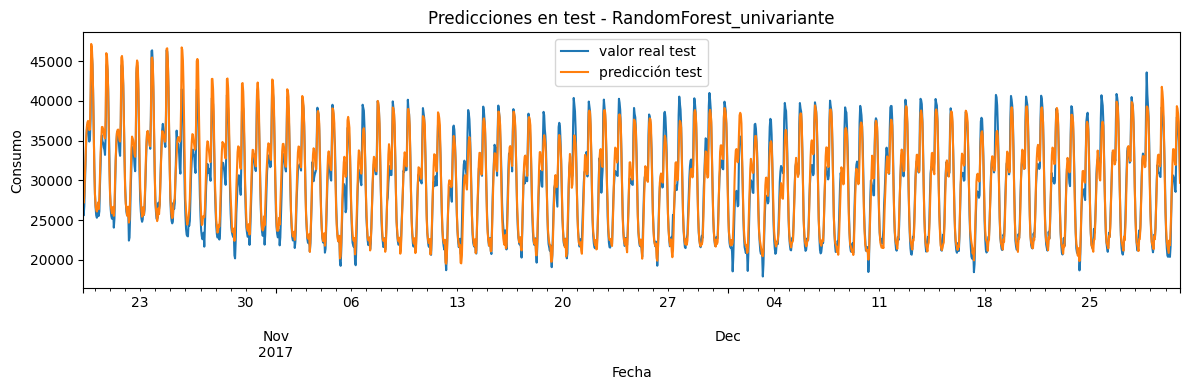

In [31]:
# Gráfico de predicciones en test del mejor modelo univariante
graficar_predicciones_test(mejor_univariante, data_test, TARGET)

## 12. Modelos con variables exógenas

Ahora se repite el proceso con las variables exógenas:

- `temperatura`
- `humedad`
- `velocidad_viento`
- `flujo_difuso_general`
- `flujo_difuso`

Importante: para usar variables exógenas en producción, sus valores futuros deben conocerse o estimarse previamente.

In [32]:

#Verificación de variables exógenas
display(data_imputed[EXOG_COLS].head())
display(data_imputed[EXOG_COLS].describe().T)

,temperatura,humedad,velocidad_viento,flujo_difuso_general,flujo_difuso
fecha,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833


,count,mean,std,min,25%,50%,75%,max
temperatura,8736.0,18.810037,5.807665,3.602167,14.403750,18.759167,22.866667,39.695000
humedad,8736.0,68.259433,15.476192,12.710000,58.324583,69.815833,81.350000,94.750000
velocidad_viento,8736.0,1.959676,2.340465,0.054667,0.078167,0.085500,4.915333,5.933667
flujo_difuso_general,8736.0,182.690925,260.807027,0.019000,0.064000,9.947417,326.487500,953.350000
flujo_difuso,8736.0,75.028105,119.692253,0.040000,0.124167,8.241250,105.883333,861.000000


In [33]:
#Random Forest con variables exógenas

# Se entrena y evalúa un modelo Random Forest usando la variable objetivo y también variables exógenas
rf_exog = buscar_hiperparametros_y_evaluar(
    nombre_modelo="RandomForest_exogenas",
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE, # Fija la semilla para que los resultados sean reproducibles
        n_jobs=-1 # Fija la semilla para que los resultados sean reproducibles
    ),
    param_grid=rf_param_grid, # Usa la grilla de hiperparámetros definida para Random Forest
    lags_grid=lags_grid,  # Prueba distintas combinaciones de lags
    estrategia=estrategia_avanzada, # Usa la mejor estrategia encontrada anteriormente
    data_train=data_train,
    data_train_val=data_train_val,
    data_full=data_imputed, # Dataset completo imputado para evaluar en test
    exog_cols=EXOG_COLS # Usa las variables exógenas como temperatura, humedad, viento y flujos difusos
)

# Muestra las mejores combinaciones encontradas por el Grid Search
display(rf_exog["resultados_grid"].head())

#muestra el MAE obtenido en test usando random forest con variables exógenas
print("MAE test RF con exógenas:", rf_exog["mae_test"])

lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

,lags,lags_label,params,mean_absolute_error,max_depth,min_samples_leaf,n_estimators
0,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",1241.738213,NaN,1.0,300.0
1,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es...",1242.578527,20.0,1.0,100.0
2,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es...",1242.647016,20.0,1.0,300.0
3,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",1249.881034,NaN,1.0,100.0
4,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",1252.428886,NaN,3.0,300.0


MAE test RF con exógenas: 1085.5671165088777


In [34]:
#LightGBM con variables exógenas
# Se entrena y evalúa un modelo LightGBM usando la variable objetivo y también variables exógenas
lgbm_exog = buscar_hiperparametros_y_evaluar(
    nombre_modelo="LightGBM_exogenas",
    estimator=LGBMRegressor(
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    param_grid=lgbm_param_grid,
    lags_grid=lags_grid,
    estrategia=estrategia_avanzada,
    data_train=data_train,
    data_train_val=data_train_val,
    data_full=data_imputed,
    exog_cols=EXOG_COLS
)

display(lgbm_exog["resultados_grid"].head())
print("MAE test LightGBM con exógenas:", lgbm_exog["mae_test"])

lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/32 [00:00<?, ?it/s]

params grid:   0%|          | 0/32 [00:00<?, ?it/s]

params grid:   0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

,lags,lags_label,params,mean_absolute_error,learning_rate,max_depth,n_estimators,num_leaves
0,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",1238.487859,0.1,3.0,300.0,31.0
1,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",1238.487859,0.1,3.0,300.0,15.0
2,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",1242.863584,0.1,5.0,300.0,31.0
3,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",1247.786024,0.1,5.0,100.0,31.0
4,"[1, 2, 3, 23, 24, 25, 47, 48, 49, 167, 168]",lags_diario_semanal,"{'learning_rate': 0.1, 'max_depth': 10, 'n_est...",1253.274874,0.1,10.0,100.0,15.0


MAE test LightGBM con exógenas: 1137.8744771676593


In [35]:
#Comparación de modelos con exógenas
#se crea una tabla para comparar los modelos que usaron variables exógenas:
#random forest con exógenas y LightGBM con exógenas.
comparacion_exog = pd.DataFrame([
    {
        "modelo": rf_exog["modelo"],
        "estrategia": rf_exog["estrategia"],
        "usa_exogenas": rf_exog["usa_exogenas"],
        "mae_validacion_grid": rf_exog["mae_validacion_grid"],
        "mae_validacion_backtesting": rf_exog["mae_validacion_backtesting"],
        "mae_test": rf_exog["mae_test"],
        "mejores_lags": str(rf_exog["mejores_lags"]),
        "mejores_params": str(rf_exog["mejores_params"])
    },
    {
        "modelo": lgbm_exog["modelo"],
        "estrategia": lgbm_exog["estrategia"],
        "usa_exogenas": lgbm_exog["usa_exogenas"],
        "mae_validacion_grid": lgbm_exog["mae_validacion_grid"],
        "mae_validacion_backtesting": lgbm_exog["mae_validacion_backtesting"],
        "mae_test": lgbm_exog["mae_test"],
        "mejores_lags": str(lgbm_exog["mejores_lags"]),
        "mejores_params": str(lgbm_exog["mejores_params"])
    }
]).sort_values("mae_test")  #ordena los modelos de menor a mayor MAE en test

display(comparacion_exog) #muestra la tabla comparativa de modelos con exógenas

# Se obtiene el nombre del modelo con menor MAE en test
mejor_exog_nombre = comparacion_exog.iloc[0]["modelo"]

# Se guarda como mejor modelo con exógenas el que haya tenido menor MAE en test
mejor_exog = rf_exog if mejor_exog_nombre == rf_exog["modelo"] else lgbm_exog

# Se muestra el nombre del mejor modelo con variables exógenas
print("Mejor modelo con exógenas:", mejor_exog["modelo"])

,modelo,estrategia,usa_exogenas,mae_validacion_grid,mae_validacion_backtesting,mae_test,mejores_lags,mejores_params
0,RandomForest_exogenas,recursiva,True,1241.738213,1241.738213,1085.567117,[ 1 2 3 23 24 25 47 48 49 167 168],"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
1,LightGBM_exogenas,recursiva,True,1238.487859,1238.487859,1137.874477,[ 1 2 3 23 24 25 47 48 49 167 168],"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


Mejor modelo con exógenas: RandomForest_exogenas


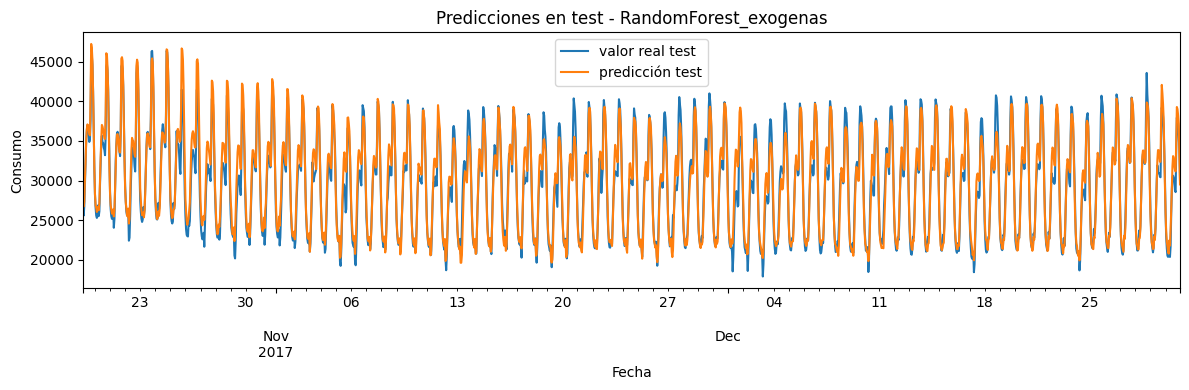

In [36]:
# Gráfico de predicciones en test del mejor modelo con variables exógenas

graficar_predicciones_test(mejor_exog, data_test, TARGET)

## 13. Comparar ambos modelos finales

Se compara:

- Mejor modelo univariante final.
- Mejor modelo con variables exógenas final.

La elección se hace usando **MAE en test**.

In [37]:
#Comparación final: univariante vs exógenas

# Se crea una tabla comparando el mejor modelo univariante contra el mejor modelo con variables exógenas
comparacion_final = pd.DataFrame([
    {
        "modelo": mejor_univariante["modelo"],
        "estrategia": mejor_univariante["estrategia"],
        "usa_exogenas": mejor_univariante["usa_exogenas"],
        "mae_test": mejor_univariante["mae_test"],
        "mejores_lags": str(mejor_univariante["mejores_lags"]),
        "mejores_params": str(mejor_univariante["mejores_params"])
    },
    {
        "modelo": mejor_exog["modelo"],
        "estrategia": mejor_exog["estrategia"],
        "usa_exogenas": mejor_exog["usa_exogenas"],
        "mae_test": mejor_exog["mae_test"],
        "mejores_lags": str(mejor_exog["mejores_lags"]),
        "mejores_params": str(mejor_exog["mejores_params"])
    }
]).sort_values("mae_test")

display(comparacion_final)

mejor_final_nombre = comparacion_final.iloc[0]["modelo"]

# Se guarda como mejor modelo final el que tenga menor MAE en test
if mejor_final_nombre == mejor_univariante["modelo"]:
    mejor_final = mejor_univariante
else:
    mejor_final = mejor_exog

# Se muestra el mejor modelo final y su error en test
print("Mejor modelo final:", mejor_final["modelo"])
print("MAE test:", mejor_final["mae_test"])

,modelo,estrategia,usa_exogenas,mae_test,mejores_lags,mejores_params
1,RandomForest_exogenas,recursiva,True,1085.567117,[ 1 2 3 23 24 25 47 48 49 167 168],"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."
0,RandomForest_univariante,recursiva,False,1097.419497,[ 1 2 3 23 24 25 47 48 49 167 168],"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."


Mejor modelo final: RandomForest_exogenas
MAE test: 1085.5671165088777


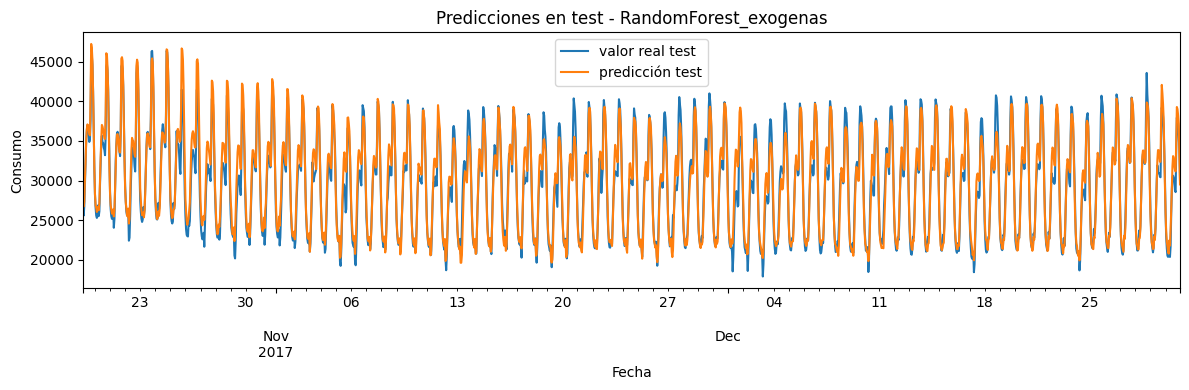

In [38]:
# Gráfico de predicciones en test del mejor modelo final

graficar_predicciones_test(mejor_final, data_test, TARGET)

## 14. Entrenar el mejor modelo con todo el dataset

Una vez elegido el mejor modelo, se entrena nuevamente usando todo el dataset disponible.

In [39]:
#entrenamiento final con todo el dataset

# Se toma el forecaster del mejor modelo final elegido anteriormente
forecaster_final = mejor_final["forecaster"]

# Se guarda si el mejor modelo final usa o no variables exógenas
usa_exog_final = mejor_final["usa_exogenas"]

# Si el mejor modelo usa variables exógenas, se entrena con la variable objetivo y las variables exógenas
if usa_exog_final:
    forecaster_final.fit(
        y=data_imputed[TARGET],
        exog=data_imputed[EXOG_COLS]
    )

# Si el mejor modelo no usa variables exógenas, se entrena solo con la variable objetivo
else:
    forecaster_final.fit(
        y=data_imputed[TARGET]
    )
# Se confirma que el modelo final fue entrenado con todo el dataset disponible
print("Modelo final entrenado con todo el dataset.")

# Se muestra la información del forecaster final
print(forecaster_final)

Modelo final entrenado con todo el dataset.
ForecasterRecursive 
Estimator: RandomForestRegressor 
Lags: [  1   2   3  23  24  25  47  48  49 167 168] 
Window features: None 
Window size: 168 
Series name: y 
Exogenous included: True 
Exogenous names: 
    temperatura, humedad, velocidad_viento, flujo_difuso_general, flujo_difuso 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2017-01-01 00:00:00'), Timestamp('2017-12-30 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators'

## 15. Guardar el mejor modelo

Se guarda el forecaster entrenado con todo el dataset y un archivo `.json` con metadatos del modelo.

In [42]:
from pathlib import Path
import json
import joblib
import pickle

# Se crea la carpeta donde se guardará el modelo final
model_dir = Path("modelos")
model_dir.mkdir(exist_ok=True)

# Se definen las rutas donde se guardarán el modelo y sus metadatos
model_path = model_dir / "mejor_modelo_tetuan.joblib"
pkl_path = model_dir / "mejor_modelo_tetuan.pkl"
metadata_path = model_dir / "mejor_modelo_tetuan_metadata.json"

# Se guarda el modelo final entrenado en un archivo .joblib
joblib.dump(forecaster_final, model_path)

# Se guarda también el modelo final entrenado en un archivo .pkl
with open(pkl_path, "wb") as f:
    pickle.dump(forecaster_final, f)

# Se crea un diccionario con información importante del modelo final
metadata = {
    "modelo": mejor_final["modelo"],
    "estrategia": mejor_final["estrategia"],
    "usa_exogenas": bool(mejor_final["usa_exogenas"]),
    "target": TARGET,
    "exog_cols": EXOG_COLS if mejor_final["usa_exogenas"] else [],
    "steps": STEPS,
    "mae_test": float(mejor_final["mae_test"]),
    "mejores_lags": str(mejor_final["mejores_lags"]),
    "mejores_params": str(mejor_final["mejores_params"]),
    "fecha_min": str(data_imputed.index.min()),
    "fecha_max": str(data_imputed.index.max()),
    "frecuencia": "h"
}

# Se guardan los metadatos en un archivo JSON
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

# Se muestran las rutas donde quedaron guardados el modelo y los metadatos
print("Modelo guardado en formato .joblib en:", model_path)
print("Modelo guardado en formato .pkl en:", pkl_path)
print("Metadatos guardados en:", metadata_path)

Modelo guardado en formato .joblib en: modelos/mejor_modelo_tetuan.joblib
Modelo guardado en formato .pkl en: modelos/mejor_modelo_tetuan.pkl
Metadatos guardados en: modelos/mejor_modelo_tetuan_metadata.json


## Ejemplo de carga posterior del modelo

Este bloque muestra cómo cargar el modelo guardado para reutilizarlo luego.

In [41]:
# Ejemplo de uso posterior

modelo_cargado = joblib.load(model_path)

# Para predecir las próximas 24 horas:
# - Si el modelo final usa exógenas, se debe pasar un DataFrame futuro con las columnas EXOG_COLS.
# - Si no usa exógenas, alcanza con indicar steps=24.

if usa_exog_final:
    print("El modelo final usa variables exógenas.")
    print("Para predecir, crear un DataFrame futuro con estas columnas:")
    print(EXOG_COLS)
    # ejemplo:
    # predicciones_futuras = modelo_cargado.predict(steps=24, exog=futuro_exog)
else:
    predicciones_futuras = modelo_cargado.predict(steps=24)
    display(predicciones_futuras.head())

El modelo final usa variables exógenas.
Para predecir, crear un DataFrame futuro con estas columnas:
['temperatura', 'humedad', 'velocidad_viento', 'flujo_difuso_general', 'flujo_difuso']


## Uso de IA generativa

Se utilizó IA generativa, específicamente ChatGPT, como herramienta de apoyo durante el desarrollo del proyecto. Su uso estuvo orientado principalmente a revisar la organización del notebook y del informe, verificar si se cumplían los puntos solicitados en la consigna, detectar posibles secciones faltantes y mejorar la claridad de algunas explicaciones.

La IA no reemplazó el trabajo realizado por el grupo, ni modificó los resultados obtenidos mediante el código. Las decisiones de modelado, procesamiento de datos, análisis de resultados y conclusiones fueron realizadas y validadas por los integrantes del equipo.

A continuación, se presentan algunos ejemplos de prompts utilizados y las respuestas obtenidas de forma resumida:

Prompt 1:
"Teniendo en cuenta los tipos de datos que maneja el notebook, creame una función que obtenga la metrica MAE sin importar cual sea el fomrato en que venga"

Respuesta resumida:


```
def extraer_mae(metric):
    if isinstance(metric, pd.DataFrame):  #revisa si la métrica viene como DataFrame
        if "mean_absolute_error" in metric.columns: #si existe la columna mean_absolute_error
            return float(metric["mean_absolute_error"].iloc[0])  #devuelve el primer valor de esa columna como número decimal
        return float(metric.iloc[0, 0]) #si no existe esa columna, devuelve el primer valor del DataFrame

    if isinstance(metric, pd.Series):   #revisa si la métrica viene como Series
        if "mean_absolute_error" in metric.index:   #si existe el índice mean_absolute_error
            return float(metric.loc["mean_absolute_error"])   #devuelve ese valor como número decimal
        return float(metric.iloc[0]) #si no existe ese índice, devuelve el primer valor de la Series
    return float(metric) #si la métrica ya viene como número, la convierte a float y la devuelve
```




Prompt 2:
“Revisá si el notebook cumple con la consigna del proyecto y decime qué falta corregir o agregar.”

Respuesta resumida:
La IA sugirió revisar que estuvieran claramente explicadas las etapas de carga de datos, limpieza, transformación temporal, selección de variables, entrenamiento del modelo, evaluación de métricas y conclusiones. También recomendó agregar explicaciones breves antes de algunos bloques de código para mejorar la comprensión.

Prompt 3:
“Dame una estructura para organizar el informe del proyecto según la consigna.”

Respuesta resumida:
La IA propuso organizar el informe en secciones como introducción, descripción del problema, dataset utilizado, procesamiento de datos, metodología, modelos aplicados, resultados, análisis de métricas y conclusiones.

Prompt 4:
“Ayudame a redactar una explicación breve sobre el problema y el dataset para incluir en la presentación.”

Respuesta resumida:
La IA ayudó a mejorar la redacción del texto, explicando que el objetivo del proyecto era predecir el consumo eléctrico de la zona 1 para las siguientes 24 horas, utilizando una serie temporal con frecuencia horaria y variables exógenas como temperatura, humedad, viento y radiación.